# Orbcloud: Quickstart Tutorial

Welcome to **orbcloud**! This notebook guides you through simulating exoplanetary parameter posteriors and visualizing them as beautiful 3D orbital probability clouds.

## Installation & Setup
Ensure you have `numpy` and `matplotlib` installed in your environment. Since we are running this in the repository folder, we will insert the local `src/` directory to the system path to import `orbcloud` directly.

In [12]:
import sys
import os
import matplotlib.pyplot as plt

# Add src/ to the Python path to import the local package
sys.path.insert(0, os.path.abspath('./src'))

from orbcloud import PlanetConfig, SystemEnsemble

## 1. Setting Up a Multi-Planet System

To represent planets in our system, we define `PlanetConfig` objects. We configure these with the parameters that physically dictate the orbit's size, shape, and 3D orientation:
- **`P_mean` / `P_std`**: Orbital Period in days.
- **`omega_mean_deg` / `omega_std_deg`**: Argument of periastron in degrees.
- **`e_mean` / `e_std`**: Eccentricity.
- **`i_deg`**: Fixed inclination in degrees (0 = face-on, 90 = edge-on).
- **`Omega_deg`**: Fixed longitude of ascending node in degrees.

For this example, we will configure a two-planet system around a Sun-like star.

In [13]:
# Initialize a system centered around a Sun-like star
system = SystemEnsemble(star_id='sun')

# 1. Inner planet 'b'
planet_b = PlanetConfig(
    name='Planet b',
    P_mean=90.0, P_std=8.0,
    omega_mean_deg=60.0, omega_std_deg=40.0,
    e_mean=0.15, e_std=0.09,
    i_deg=0.0, Omega_deg=0.0  # Try changing these manually (e.g. 60.0, 20.0)!
)

# 2. Outer planet 'c'
planet_c = PlanetConfig(
    name='Planet c',
    P_mean=260.0, P_std=14.0,
    omega_mean_deg=210.0, omega_std_deg=45.0,
    e_mean=0.25, e_std=0.10,
    i_deg=0.0, Omega_deg=0.0  # Try changing these manually (e.g. 60.0, 20.0)!
)

# Add planets to our ensemble (simulating 1000 orbital paths per planet)
system.add_planet(planet_b, num_samples=1000)
system.add_planet(planet_c, num_samples=1000)

## 2. Visualizing the Full Probability Cloud

Now we render the visual. 

By default, `plot_system()` will generate **both** 2D and 3D subplots side-by-side using the optimized parameter defaults (`alpha_2d=0.02` and `alpha_3d=0.01`). We also enable the gray reference plane at $Z=0$ in the 3D subplot.

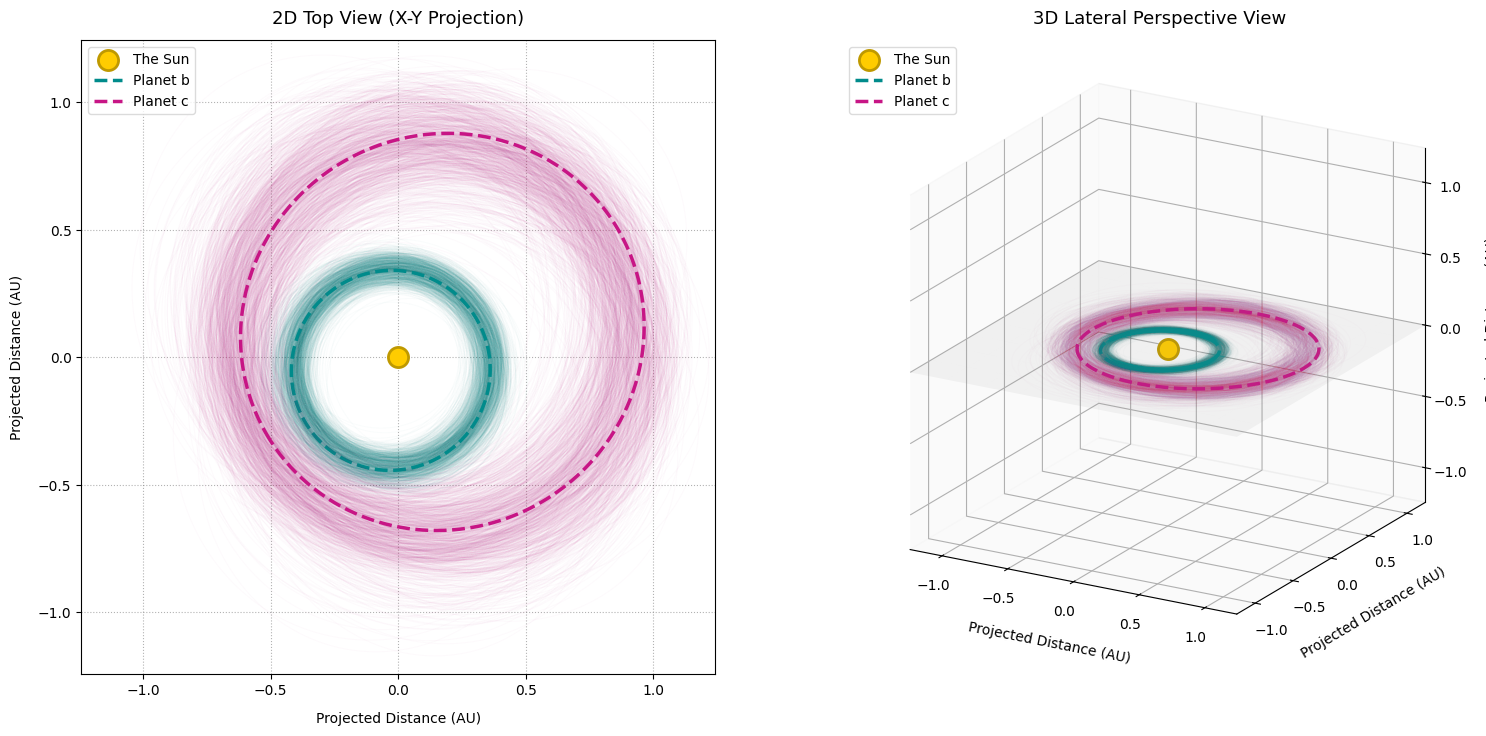

In [14]:
%matplotlib inline

# Plot the system using library defaults (dimension='both' is the default)
system.plot_system(show_reference_plane=True)

plt.show()

## 3. Filtering Planet Visibility and plotting 2D or 3D only

If you want to view a single projection (e.g. 2D top view only) or isolate a planet, you can easily filter parameters:

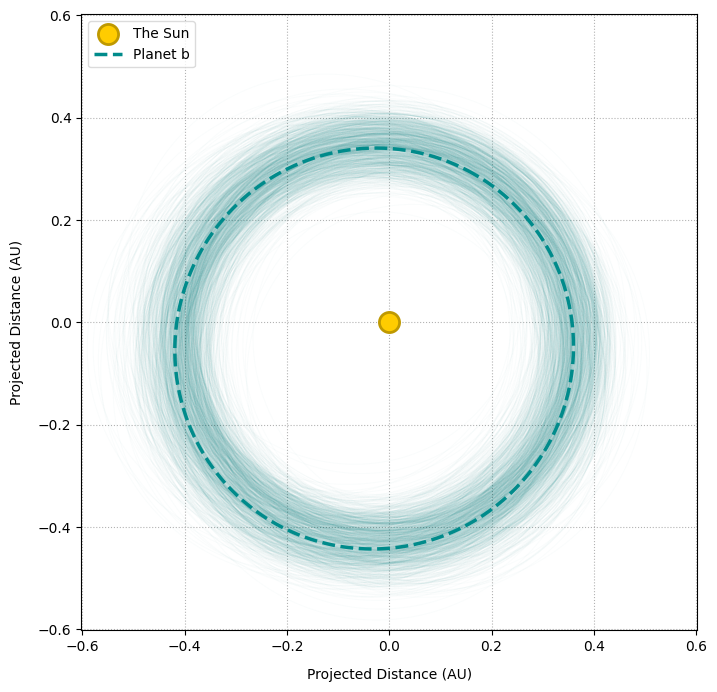

In [15]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

# Render 2D top view only for Planet b
system.plot_system(ax=ax, dimension='2d', planets_to_show=['Planet b'])

plt.show()

## 4. Defining a Custom Star

You can also define a custom central star by passing `star_name`, `star_mass`, and `star_type` (spectral type: O, B, A, F, G, K, or M) when initializing the `SystemEnsemble`. The star's visual properties (color and size) will automatically be resolved based on its spectral type.

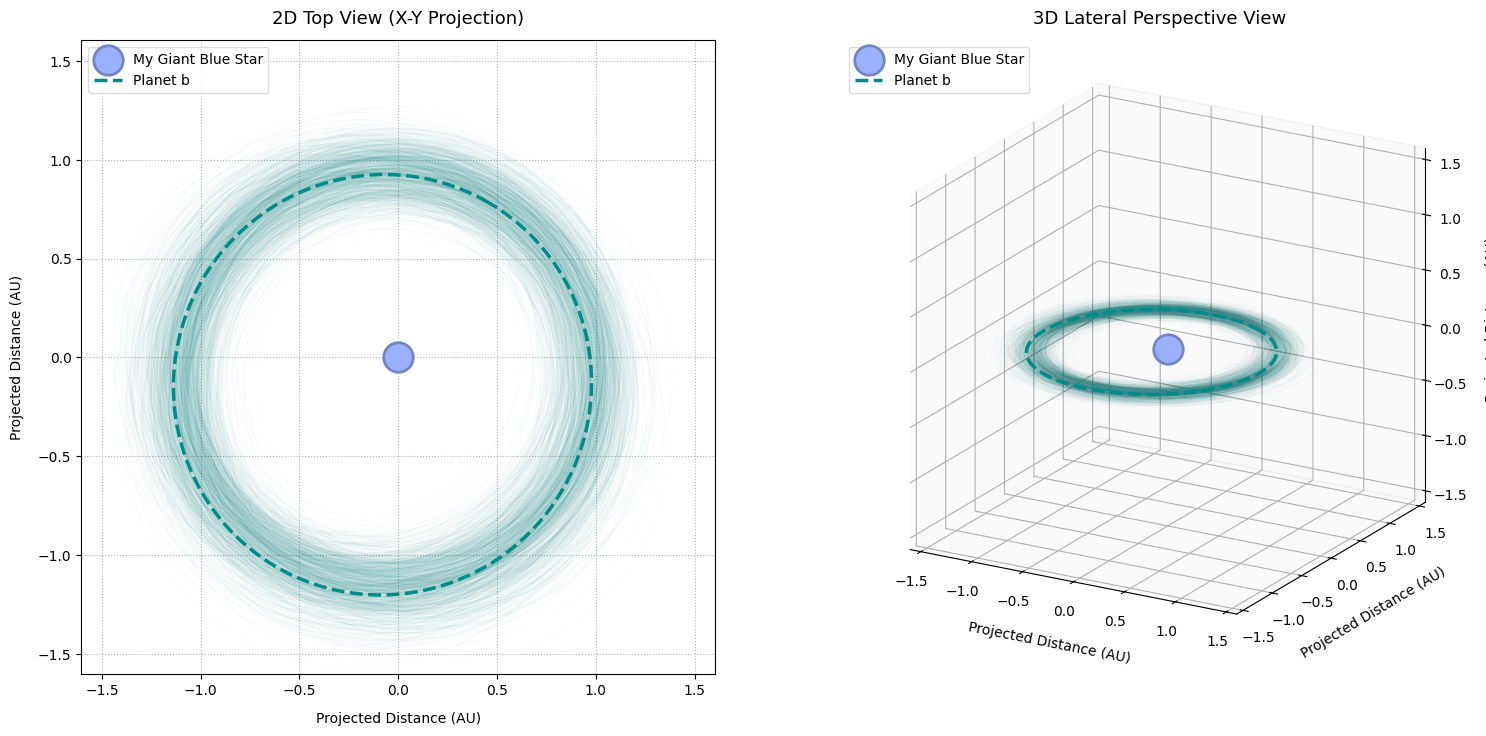

In [16]:
# Initialize a system centered around a custom massive O-type star
custom_system = SystemEnsemble(star_name='My Giant Blue Star', star_mass=20.0, star_type='O')

# Add the inner planet 'b'
custom_system.add_planet(planet_b, num_samples=1000)

# Plot the system to see the custom blue central star!
custom_system.plot_system(dimension='both', show_reference_plane=False)

plt.show()